In [78]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import copy

In [157]:
image = cv2.imread('sar_3.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

***Линии Хафа***

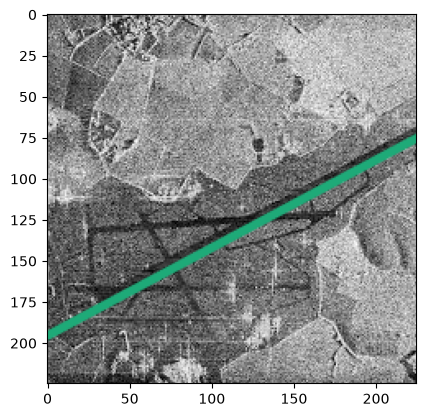

In [158]:
canny = cv2.Canny(image_gray, 130, 400, apertureSize=3)

lines = cv2.HoughLines(canny, 1, np.pi / 180, 120)

if lines is not None:
    for i in range(0, len(lines)):
        rho = lines[i][0][0]
        theta = lines[i][0][1]
        a = math.cos(theta)
        b = math.sin(theta)
        x0 = a * rho
        y0 = b * rho
        pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
        pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
        cv2.line(image_rgb, pt1, pt2, (30, 170, 120), 3, cv2.LINE_AA)

plt.imshow(image_rgb)

***Точечная бинаризация***

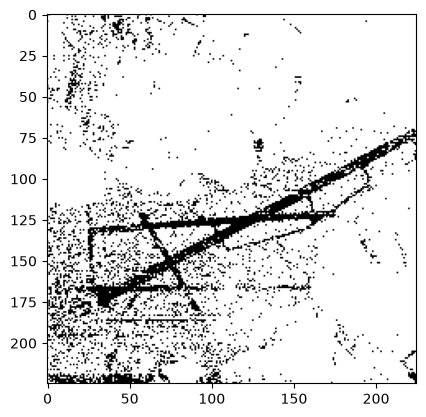

In [91]:
bin_img = copy.deepcopy(image_gray)
T  = 70
bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255

plt.imshow(bin_img, cmap="gray")

***Отсу***

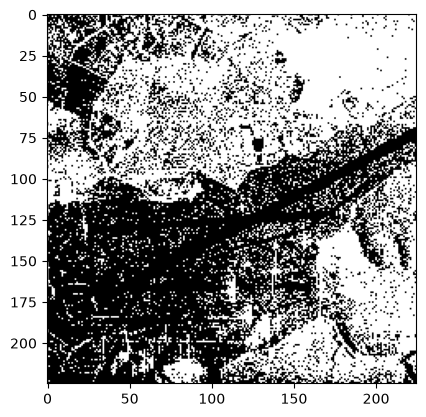

In [108]:
_,th2 = cv2.threshold(image_gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

plt.imshow(th2, cmap="gray")

***Адаптивная***

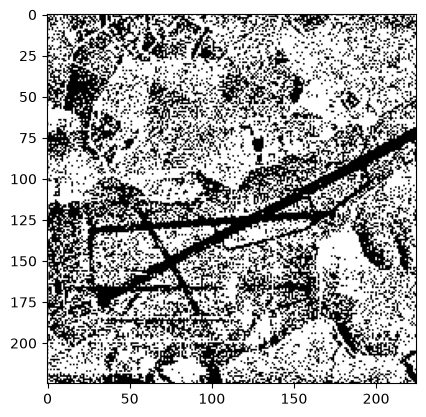

In [109]:
th3 = cv2.adaptiveThreshold(image_gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv2.THRESH_BINARY,119,10)

plt.imshow(th3, cmap="gray")

**Точечная бинаризация справилась с работой лучше всего**